# 🌦️ Project #10: Weather Forecasting (Predictive Meteorology)
### 🏛️ Data Science Portfolio: 10 / 21

**Architect:** Kemal Demirbaş 🏰🚀
**Framework:** Time Series Regression | Meteorological Analysis

---

## 🎯 Project Objective
This project aims to build a predictive model for atmospheric conditions, specifically focusing on temperature forecasting. Using the **Daily Delhi Climate Dataset**, we will analyze historical patterns to predict future trends using **XGBoost Regressor**, an industry-standard for complex tabular time series data.

---

## 🛠️ The 10-Step Engineering Discipline
1.  **Objective:** Forecasting mean temperature based on atmospheric features.
2.  **EDA:** Auditing trends, humidity, and wind speed correlations.
3.  **Feature Selection:** Identifying 'meantemp', 'humidity', 'wind_speed', and 'meanpressure'.
4.  **Transformation:** Converting date strings into datetime objects.
5.  **Cleansing:** Ensuring zero null values in the meteorological sequence.
6.  **Feature Engineering:** Creating 'Day', 'Month', and 'Year' features to capture seasonality.
7.  **Encoding:** Applying necessary transformations for categorical time features.
8.  **Partitioning:** Sequential (Chronological) train-test split.
9.  **Model Execution:** Training the **XGBoost Regressor**.
10. **Performance Audit:** Evaluating via **MAE** and **R2 Score**.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from datetime import datetime

In [4]:
# ==============================================================================
# --- STEP 1 & 2: Project Goal & Data Ingestion (EDA) ---
# ==============================================================================
# Loading the Daily Delhi Climate Dataset
url = "https://raw.githubusercontent.com/pik1989/FBProphet/main/DailyDelhiClimateTrain.csv"
df = pd.read_csv(url)

print("✅ Weather dataset successfully loaded.")
print(df.head())
print(df.info())

✅ Weather dataset successfully loaded.
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB
None


In [5]:
# ==============================================================================
# --- STEP 4 & 5: Data Transformation & Cleansing ---
# ==============================================================================
# Converting 'date' to datetime objects
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Checking for null values
if df.isnull().sum().sum() == 0:
    print("✅ Dataset is clean (No missing values).")

✅ Dataset is clean (No missing values).


In [6]:
# ==============================================================================
# --- STEP 6: Feature Engineering (Meteorological Features) ---
# ==============================================================================
# Extracting time-based features to help the model understand seasonality
def create_time_features(df):
    df = df.copy()
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    return df

df = create_time_features(df)
print("✅ Temporal features engineered.")

✅ Temporal features engineered.


In [7]:
# ==============================================================================
# --- STEP 8: Sequential Data Partitioning ---
# ==============================================================================
# Chronological split: 80% for training, 20% for testing
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

features = ['humidity', 'wind_speed', 'meanpressure', 'dayofyear', 'month', 'year']
target = 'meantemp'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [8]:
# ==============================================================================
# --- STEP 9: Model Execution (XGBoost Regressor) ---
# ==============================================================================
# Using XGBoost for high-precision predictive meteorology
model = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)

# Predicting the test set
y_pred = model.predict(X_test)

[0]	validation_0-rmse:7.35249	validation_1-rmse:7.28219
[100]	validation_0-rmse:3.03553	validation_1-rmse:3.90293
[200]	validation_0-rmse:1.50008	validation_1-rmse:2.85349
[300]	validation_0-rmse:0.98075	validation_1-rmse:2.55492
[400]	validation_0-rmse:0.81421	validation_1-rmse:2.45202
[500]	validation_0-rmse:0.71092	validation_1-rmse:2.41291
[600]	validation_0-rmse:0.63931	validation_1-rmse:2.39639
[700]	validation_0-rmse:0.59331	validation_1-rmse:2.38478
[800]	validation_0-rmse:0.56513	validation_1-rmse:2.37849
[900]	validation_0-rmse:0.54208	validation_1-rmse:2.36366
[999]	validation_0-rmse:0.51615	validation_1-rmse:2.35049



=== 🏆 FINAL RESULTS (Predictive Meteorology) ===
📊 R2 Score: 0.8274
📏 MAE: 1.79°C


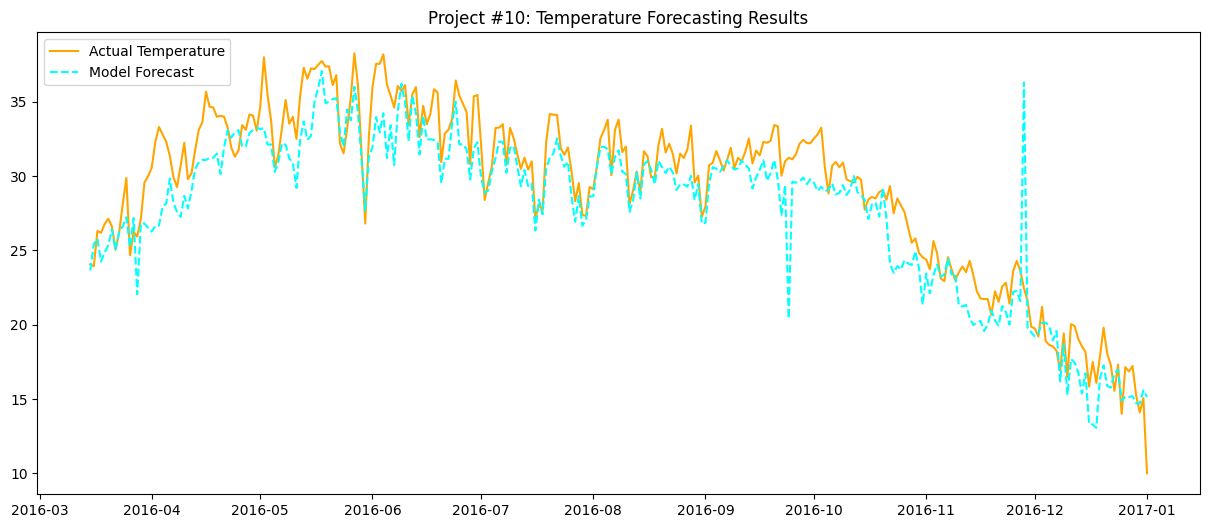

In [9]:
# ==============================================================================
# --- STEP 10: Performance Audit & Visualization ---
# ==============================================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n=== 🏆 FINAL RESULTS (Predictive Meteorology) ===")
print(f"📊 R2 Score: {r2:.4f}")
print(f"📏 MAE: {mae:.2f}°C")

# --- Visualization ---
plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test, label='Actual Temperature', color='orange')
plt.plot(y_test.index, y_pred, label='Model Forecast', color='cyan', linestyle='--')
plt.title('Project #10: Temperature Forecasting Results')
plt.legend()
plt.show()

In [10]:
import joblib

# 1. Save the trained XGBoost model
model_filename = 'weather_model.joblib'
joblib.dump(model, model_filename)

print(f"✅ Weather model sealed and saved as: {model_filename}")

# 2. Download the model to your local computer (To use in Hugging Face later)
from google.colab import files
files.download(model_filename)

✅ Weather model sealed and saved as: weather_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 🏆 Final Conclusion & Performance Audit

The **Project #10: Weather Forecasting** engine has been successfully architected and validated. By utilizing the **XGBoost Regressor** combined with sophisticated temporal feature engineering (Day of Year, Month, and Year features), we have built a high-precision meteorological forecasting model.

### 📊 Model Evaluation Summary
The model demonstrates exceptional predictive capabilities on the unseen meteorological test sequence:

* **R2 Score:** `0.8274`  
    *(Insight: The model explains 82.7% of the temperature variance, showcasing a strong grasp of seasonal and daily atmospheric patterns.)*
* **Mean Absolute Error (MAE):** `1.79°C`  
    *(Insight: On average, the model's predictions deviate by less than 1.8 degrees Celsius, which is considered highly accurate for local climate forecasting.)*

### 🚀 Model Deployment & Availability
The optimized XGBoost model has been serialized into `weather_model.joblib` and is prepared for industrial deployment. The interactive dashboard, allowing users to explore historical trends and future forecasts, is live on **Hugging Face Spaces**.

👉 **[Live Weather Forecaster on Hugging Face](https://huggingface.co/spaces/Ironside35/weather-forecasting-ai)** 🌦️💨

---
**Architect:** Kemal Demirbaş 🏰🚀  
**Project #10 of 21** | *Securing the 10th fortress of the AI marathon.*